In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, load_gbs_gesis, load_gbs_allensbach
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest, train_feature_weighted_decision_tree
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import sample
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs_without_cv, mrs
from utils.metrics import compute_classification_metrics_random_forest

2024-04-24 10:05:49.014840: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-24 10:05:49.014890: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-24 10:05:49.016122: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-24 10:05:49.023437: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-24 10:05:49.978094: W tensorflow/compiler/tf2

In [2]:
def compute_feature_weights_softmax(budget, feature_importance):
    weights =  np.exp(-feature_importance / budget)
    return weights / np.sum(weights)

In [3]:
def compute_feature_weights(budget, feature_importance):
    max_importance = np.max(feature_importance)
    feature_importance = feature_importance / max_importance 
    scaled_feature_importance = feature_importance * budget
    scaled_feature_importance = 1 - scaled_feature_importance
    return scaled_feature_importance 

In [4]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
##N = df[df["label"] == 1]
#R = df[df["label"] == 0]
N, R = sample(
           "less_negative_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.9,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [5]:
drop_ids, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
_, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

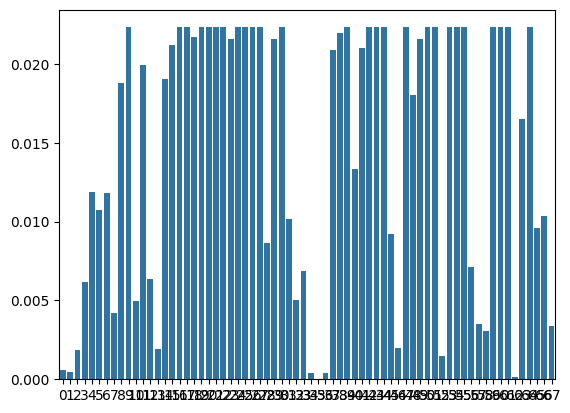

In [6]:
weights = compute_feature_weights_softmax(0.001, feature_importance_cv)
sns.barplot(weights / np.sum(weights))

In [7]:
seed = 5
weight_method = compute_feature_weights_softmax
max_features = "sqrt"
max_depth= None
# budgets = [0, 0.25, 0.5, 0.9]
budgets = [1, 0.1, 0.01, 0.001, 0.0001]
auroc_method = train_feature_weighted_random_forest
n_estimators=500

In [22]:
for budget in budgets:
   feature_weights = weight_method(budget, feature_importance_cv)
   auroc = compute_test_metrics_fw_mrs(
       dropped_N,
       R,
       columns,
       random_state=seed,
       feature_weights=feature_weights,
       method=auroc_method,
       draw_with_feature_weights=True,
       class_weight="balanced",
       max_features="sqrt",
       splitter="feature_weighted_best",
       n_splits_test=50,
       n_estimators=n_estimators,
   )
   print(f"{budget}: {auroc:2f}")

1.0: 0.481640


1: 0.573855\
0.01: 0.561661\
0.005: 0.552442

In [9]:
sample_weights = np.ones(len(N))
# weight_method = compute_feature_weights
#budgets = [0, 0.25, 0.5, 0.9]
budgets = [1.0, 0.05, 0.01]
feature_weights_list = []
for budget in budgets:
    feature_weights = compute_feature_weights(budget, feature_importance)
    feature_weights_list.append(feature_weights)

In [14]:
for i,budget in enumerate(budgets):
    if budget == 1.0:
        draw_with_feature_weights = False 
    else: 
        draw_with_feature_weights = True
    auroc, auprc = compute_classification_metrics_random_forest(
            N,
            R,
            columns,
            sample_weights,
            feature_weights_list[i],
            target,
            random_state=seed,
            draw_with_feature_weights=draw_with_feature_weights,
            class_weight="balanced",
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=1000,
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

1.0 Auroc: 0.864677807686025
1.0 AUPRC: 0.8382593322708727

0.05 Auroc: 0.8646684456657396
0.05 AUPRC: 0.8395741259544525

0.01 Auroc: 0.8662380367908029
0.01 AUPRC: 0.8422901532505566



In [11]:
sample_weights = np.ones(len(N))
# weight_method = compute_feature_weights
#budgets = [0, 0.25, 0.5, 0.9]
budgets = [1.0, 0.05, 0.01]
feature_weights_list = []
for budget in budgets:
    feature_weights = compute_feature_weights_softmax(budget, feature_importance)
    feature_weights_list.append(feature_weights)

In [12]:
for i,budget in enumerate(budgets):
   auroc, auprc = compute_classification_metrics_random_forest(
           N,
           R,
           columns,
           sample_weights,
           feature_weights_list[i],
           target,
           random_state=seed,
           draw_with_feature_weights=True,
           class_weight="balanced",
           n_splits=10,
           splitter="feature_weighted_best",
           n_estimators=1000,
   )
   print(f"{budget} Auroc: {auroc}")
   print(f"{budget} AUPRC: {auprc}\n")

1.0 Auroc: 0.8638581466686381
1.0 AUPRC: 0.8387852124065868

0.05 Auroc: 0.8646684456657396
0.05 AUPRC: 0.8395741259544525

0.01 Auroc: 0.8662380367908029
0.01 AUPRC: 0.8422901532505566



In [13]:
# dropped_N = dropped_N.drop(drop_ids)